<div align="center">
  <a href="https://colab.research.google.com/github/PrunaAI/ai-efficiency-courses/blob/main/solutions/07-finetune_llm.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

---
**💡 Tip**: Click the button above to open this notebook in Google Colab for free GPU access!

## Installation

This notebook includes automatic setup cells that will install the project from git repository with UV.

**Note**: Run the setup cells below before starting the exercises.

In [ ]:
# Install project directly from git repository
!uv pip install git+https://github.com/PrunaAI/ai-efficiency-courses.git

## Utility cells

During the course, we'll leverage some course utilities to streamline our workflow. These utilities are located in the `course` package, which can simply be imported given that we installed the project from git repository above.
You can find the source code [here](https://github.com/PrunaAI/ai-efficiency-courses/tree/main/course).

These utilities will help us:
- Load and manage lists of model ids that we have verified to work.
- Generate informative plots for model analysis.
- Iterate efficiently over evaluation and model configuration options.

Let's first load our models. We will use `SMALL_MODEL_IDS`, which are sub 1B parameters which should be easy to download and load into memory. We recommend starting with these smaller models but feel free to experiment with other models until you reach your GPU memory limit!

In [ ]:
from course import SMALL_MODEL_IDS, MEDIUM_MODEL_IDS, LARGE_MODEL_IDS, ALL_MODEL_IDS

MODEL_IDS = SMALL_MODEL_IDS
# MODEL_IDS = MEDIUM_MODEL_IDS
# MODEL_IDS = LARGE_MODEL_IDS
# MODEL_IDS = ALL_MODEL_IDS

MODEL_IDS

We also recommend to set a custom cache directory for models. Loading models can take significant disk space. To avoid filling up your default disk, we recommend setting a custom cache directory for downloaded models. You can do this by running the following in a terminal or in a notebook cell:

In [ ]:
# Replace <path_to_cache> with your desired cache path
import os

CACHE_PATH = "<path_to_cache>"
os.environ["TORCH_HOME"] = CACHE_PATH
os.environ["HF_HOME"] = CACHE_PATH
os.environ["HUGGINGFACE_HUB_CACHE"] = CACHE_PATH
os.environ["HUGGINGFACE_ASSETS_CACHE"] = CACHE_PATH

You can also clear the cache by running the following cell:

In [ ]:
from course.models import clear_cache

clear_cache(CACHE_PATH)

# 07: Finetune a Quantized LLM to Recover Performance

Welcome to the next lecture of the LLM Efficiency course! 🎯

In this tutorial, we’ll explore how to finetune Large Language Models (LLMs) to improve their performance after applying some compression techniques. After quantization and pruning, we can achieve a significant reduction in the model size and inference time. However, this comes at the cost of accuracy. Finetuning the model can help us to recover the quality of the model. This can be done with the so-called Parameter-Efficient Retraining after Pruning (PERP). The content from the chapter 5 [slides](https://github.com/PrunaAI/ai-efficiency-courses/blob/main/slides/05-finetune_language_models.pdf) will help you to go through this notebook.

By the end of this lecture, you will:
- Understand the basics and importance of recovering the performance of quantized LLMs.
- Learn how to prepare data and configure training for PERP.
- Evaluate and analyze the results of your finetuned models.
- Gain hands-on experience with practical tools and efficient workflows for PERP.

Let's get started and see how you can make quantized LLMs work even better for your needs!

## 1. Imports

As we've already installed the project, we can import the necessary libraries. We will be using `transformers` for this tutorial as interface to the model and tokenizer. On top of that, we will be using `pruna_pro` for evaluation. We recommend to checkout the [Pruna documentation](https://docs.pruna.ai/en/stable/index.html) for access to AI efficiency functions.

Take into account that for this notebook, we will be using `pruna_pro` package. For more information, please check the [documentation](https://docs.pruna.ai/en/stable/docs_pruna_pro/user_manual/pruna_pro.html).

In [3]:
import copy
import random

from datasets import Dataset, load_dataset
from pruna.data.utils import split_train_into_train_val_test
from pruna.evaluation.metrics import (
    TorchMetricWrapper,
    TotalTimeMetric,
)
from pruna_pro import SmashConfig, smash
from transformers import AutoModelForCausalLM, AutoTokenizer


Beyond external libraries, this course comes with the `course` local package which contains a lot of utils that you can use in the notebooks. We will be using `evaluate_model` function to evaluate the model and `create_comparison_plots` for visualization.

In [4]:
from course import create_comparison_plots, evaluate_model

## 2. Benchmarking LLM Recovery Methods

We recommend to check the [configuration guide](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/configure.html) and [recoverers overview](https://docs.pruna.ai/en/stable/compression.html#recoverers) in the pruna documentation for the implementation details.

### 2.1 Evaluate the Base Model Quality

In this section, you'll evaluate the base model so you can compare the results with the finetuned versions

**Why is this important?**
Evaluating a base model establishes a performance baseline. This is crucial to measure and compare the gainings after fine-tuning the model. By measuring both perplexity and latency, you can assess the trade-offs between model quality and speed.

**Your tasks:**
1. Create `smash_evaluate_perplexity_time` function to measure both perplexity (accuracy) and total time or latency (efficiency) for the base model on WikiText.
2. Optionally, repeat the experiment with different LLMs or datasets to compare results.

**Key questions to answer:**
- What is the base model’s perplexity?
- Which are the trade-offs between perplexity and latency?

In [5]:
def smash_evaluate_perplexity_time(
    model_id, tokenizer=None, smash_config=None, dataset="WikiText"
) -> dict:
    """
    Evaluate the perplexity and total time of a model on a dataset.

    Args:
        model_id: The model to evaluate.
        tokenizer: The tokenizer to use.
        smash_config: The configuration to use for the model.
        dataset: The dataset to use for the evaluation.

    Returns:
        A dictionary with the perplexity and total time of the model.
    """

    ### To Complete ###
    model = AutoModelForCausalLM.from_pretrained(model_id).cuda()
    model_copy = copy.deepcopy(model)

    if tokenizer is None:
        tokenizer = AutoTokenizer.from_pretrained(model_id)

    if smash_config:
        model_copy = smash(
            model=model_copy, smash_config=smash_config, token=os.environ["PRUNA_TOKEN"]
        )
    else:
        model_copy = model_id
    metrics = [
        TotalTimeMetric(
            n_iterations=100,
            n_warmup_iterations=10,
            device="cuda",
            timing_type="sync",
        ),
        TorchMetricWrapper(metric_name="perplexity", call_type="single"),
    ]

    results = evaluate_model(
        model_id_or_pruna_model=model_copy,
        tokenizer_id_or_tokenizer=tokenizer,
        metrics=metrics,
        dataset=dataset,
    )
    ### End of To Complete ###
    return results

In [6]:
# Select the model to evaluate
model_id = MODEL_IDS[0]

### To Complete ###
baseline_results = smash_evaluate_perplexity_time(model_id=model_id)
print(baseline_results)
### End of To Complete ###

INFO - Using best available device: 'cuda'
INFO - Using call_type: y_gt for metric perplexity
INFO - Using best available device: 'cuda'
INFO - Using max_seq_len of tokenizer: None
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x76c94b4220e0>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=49.46204376220703, higher_is_better=False, metric_units=None), MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=400.36284923553467, higher_is_better=None, metric_units=None)]



### 2.2 Finetune with In-Distribution Data

In this section, you'll explore how finetuning a quantized LLM with in-distribution data (WikiText) can impact both model quality and efficiency.

**Why is this important?**
Quantization often reduces model quality due to compression, but finetuning can help recover lost performance. By adapting the model with data similar to the evaluation set, you’ll test whether quality improves without significantly affecting inference latency.

**Your tasks:**
1. Apply Quanto quantization to the base model using a `SmashConfig` object.
2. Finetune the quantized model in-place.
3. Evaluate its perplexity (accuracy) and inference latency (efficiency).
4. Add the WikiText dataset to the `SmashConfig` object.
5. Compare the results to the unmodified and quantized-only baselines.

**Key questions to answer:**
- Does finetuning improve the model's performance after quantization?
- How does finetuning affect inference latency, and what might explain any observed changes?

As you work through this, observe the trade-offs between model quality and speed, and discuss your findings.

In [7]:
tokenizer = model_id

### To Complete ###
smash_config = SmashConfig()
smash_config.add_tokenizer(tokenizer)
smash_config.add_data("WikiText", tokenizer=tokenizer)
smash_config["quantizer"] = "quanto"
smash_config["quanto_weight_bits"] = "qint4"
smash_config["recoverer"] = "text_to_text_inplace_perp"
# smash_config['recoverer'] = "text_to_text_perp"
### End of To Complete ###

results_in_distribution = smash_evaluate_perplexity_time(
    model_id=model_id, smash_config=smash_config
)
print(results_in_distribution)

INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Verifying Pruna token.
INFO - You have used 44045 hours this month.
INFO - Token was verified!
INFO - Starting quantizer quanto...
INFO - quantizer quanto was applied successfully.
INFO - Starting recoverer text_to_text_inplace_perp...
INFO - You have used 44045 hours this month.
INFO - Token was verified!
WARNING - Skipped 3.86e+07 head parameters that were not trainable due to quantization.
INFO - Recovering with PERP: norm + bias, totaling 1.21e+05 parameters.


Step,Training Loss
2194,3.972100
4388,3.815000
6582,3.748500
8776,3.736600
10970,3.716800
13164,3.727100
15358,3.693100
17552,3.709300


INFO - recoverer text_to_text_inplace_perp was applied successfully.
INFO - You have used 44058 hours this month.
INFO - Token was verified!
INFO - Using best available device: 'cuda'
INFO - Using call_type: y_gt for metric perplexity
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x76c94b4220e0>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=32.87351608276367, higher_is_better=False, metric_units=None), MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=1572.6455278396606, higher_is_better=None, metric_units=None)]



### 2.3 Finetune with Varying Amounts of In-Distribution Data

In this section, you'll investigate how the amount of in-distribution data used for finetuning a quantized LLM (using Quanto) affects both model quality and efficiency.

**Why is this important?**
Finetuning with more representative in-distribution data should enhance performance recovery after quantization, whereas finetuning with less representative data might yield smaller gains. Understanding this helps you design the finetuning strategy when working with limited data sources.

**Your task:**
- Finetune a quantized LLM (in-place or by adding parameters) with different sizes of WikiText data, then evaluate its perplexity and inference latency.
- Load the WikiText dataset from `mikasenghaas/wikitext-2` and split it into train, validation, and test sets.
- Select the number of rows from the train set you want to use for training, testing and validation.
- Add the dataset to the `SmashConfig` object.

**Key questions to answer:**
- Does increasing the amount of finetuning data improve model performance?
- How does the amount of data used for finetuning impact inference latency, and why?

In [8]:
tokenizer = model_id

### To Complete ###
train_ds, val_ds, test_ds = load_dataset(
    "mikasenghaas/wikitext-2", split=["train", "validation", "test"]
)
train_ds = train_ds.select(range(1000))

smash_config = SmashConfig()
smash_config.add_tokenizer(tokenizer)
smash_config.add_data((train_ds, val_ds, test_ds), collate_fn="text_generation_collate")
smash_config["quantizer"] = "quanto"
smash_config["quanto_weight_bits"] = "qint4"
smash_config["recoverer"] = "text_to_text_inplace_perp"
# smash_config['recoverer'] = "text_to_text_perp"
### End of To Complete ###

results_varying_data = smash_evaluate_perplexity_time(
    model_id=model_id, smash_config=smash_config
)
print(results_varying_data)

INFO - Using best available device: 'cuda'
INFO - Using max_seq_len of tokenizer: None
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Verifying Pruna token.
INFO - You have used 44059 hours this month.
INFO - Token was verified!
INFO - Starting quantizer quanto...
INFO - quantizer quanto was applied successfully.
INFO - Starting recoverer text_to_text_inplace_perp...
INFO - You have used 44059 hours this month.
INFO - Token was verified!
WARNING - Skipped 3.86e+07 head parameters that were not trainable due to quantization.
INFO - Recovering with PERP: norm + bias, totaling 1.21e+05 parameters.


Step,Training Loss
125,4.327300
250,3.946700
375,4.015400
500,3.986300
625,3.921800
750,3.917400
875,3.898200
1000,3.934500


INFO - recoverer text_to_text_inplace_perp was applied successfully.
INFO - You have used 44059 hours this month.
INFO - Token was verified!
INFO - Using best available device: 'cuda'
INFO - Using call_type: y_gt for metric perplexity
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x76c94b4220e0>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=39.39737319946289, higher_is_better=False, metric_units=None), MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=1579.5280313491821, higher_is_better=None, metric_units=None)]



### 2.4 Finetune with Random Data

Now we've seen how training size influences the performance of a finetuned model, you'll explore how finetuning a quantized LLM with random (out-of-distribution) data affects model quality and inference latency.

**Why is this important?**
Using random data introduces noise so it is expected to worsen the model. However, this serves as a useful baseline to contrast against finetuning with in-distribution or representative data.

**Your tasks:**
- Finetune a quantized LLM (in-place or by adding parameters) using randomly generated text data, then evaluate its perplexity and inference latency on the WikiText dataset.
- Generate random data.
- Add the dataset to the `SmashConfig` object.
- Evaluate the model's perplexity and inference latency.

**Key questions to answer:**
- Does finetuning with random data lead to any performance improvement?
- How does this affect inference latency, and why?

In [9]:
tokenizer = model_id

### To Complete ###
dataset = Dataset.from_dict(
    {
        "text": [
            "".join([chr(random.randint(97, 122)) for _ in range(100)])
            for _ in range(1000)
        ]
    }
)
train_ds, val_ds, test_ds = split_train_into_train_val_test(dataset, seed=42)

smash_config = SmashConfig()
smash_config.add_tokenizer(tokenizer)
smash_config.add_data((train_ds, val_ds, test_ds), collate_fn="text_generation_collate")
smash_config["device"] = "cuda"
smash_config["quantizer"] = "quanto"
smash_config["quanto_weight_bits"] = "qint4"
smash_config["recoverer"] = "text_to_text_inplace_perp"
# smash_config['recoverer'] = "text_to_text_perp"


### End of To Complete ###

results_random_data = smash_evaluate_perplexity_time(
    model_id=model_id, smash_config=smash_config
)
print(results_random_data)

INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Verifying Pruna token.
INFO - You have used 44060 hours this month.
INFO - Token was verified!
INFO - Starting quantizer quanto...
INFO - quantizer quanto was applied successfully.
INFO - Starting recoverer text_to_text_inplace_perp...
INFO - You have used 44060 hours this month.
INFO - Token was verified!
WARNING - Skipped 3.86e+07 head parameters that were not trainable due to quantization.
INFO - Recovering with PERP: norm + bias, totaling 1.21e+05 parameters.


Step,Training Loss
100,6.018300
200,5.827200
300,5.742400
400,5.720000
500,5.700300
600,5.677500
700,5.710000
800,5.709800


INFO - recoverer text_to_text_inplace_perp was applied successfully.
INFO - You have used 44061 hours this month.
INFO - Token was verified!
INFO - Using best available device: 'cuda'
INFO - Using call_type: y_gt for metric perplexity
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x76c94b4220e0>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=2763.590087890625, higher_is_better=False, metric_units=None), MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=1581.9574069976807, higher_is_better=None, metric_units=None)]



### 2.5 Finetune LLMs with Out-of-Distribution Data

In this section, you'll investigate how finetuning a quantized large language model (LLM) with out-of-distribution (OOD) data—such as text from a different domain—impacts both model quality and inference latency.

**Why is this important?**
Finetuning with out-of-distribution data can be challenging and result inunpredictable effects. It can sometimes hurt performance on the evaluation set due to domain mismatch, or in rare cases provide indirect benefits by improving generalization.

**Your tasks:**
- Finetune a quantized LLM (using Quanto, either in-place or by adding parameters) with OOD data (e.g., BookCorpus), and then evaluate its perplexity and inference latency on the WikiText dataset.
- Load a dataset, e.g. the BookCorpus dataset from `SamuelYang/bookcorpus` and split it into train, validation, and test sets.
- Prepare and add the OOD dataset to the `SmashConfig` object.
- Measure and compare the model's performance before and after finetuning.

**Key questions to answer:**
- Does finetuning with out-of-distribution data lead to any performance improvement on WikiText?
- How does this affect inference latency, and what might explain any observed changes?

In [10]:
tokenizer = model_id

### To Complete ###
train_ds = load_dataset("SamuelYang/bookcorpus")["train"]
train_ds, val_ds, test_ds = split_train_into_train_val_test(train_ds, seed=42)
train_ds = train_ds.select(range(1000))
val_ds = val_ds.select(range(100))
test_ds = test_ds.select(range(100))

smash_config = SmashConfig()
smash_config.add_tokenizer(tokenizer)
smash_config.add_data((train_ds, val_ds, test_ds), collate_fn="text_generation_collate")
smash_config["device"] = "cuda"
smash_config["quantizer"] = "quanto"
smash_config["quanto_weight_bits"] = "qint4"
smash_config["recoverer"] = "text_to_text_inplace_perp"
# smash_config['recoverer'] = "text_to_text_perp"

### End of To Complete ###

results_out_of_distribution = smash_evaluate_perplexity_time(
    model_id=model_id, smash_config=smash_config
)
print(results_out_of_distribution)

INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Verifying Pruna token.
INFO - You have used 44061 hours this month.
INFO - Token was verified!
INFO - Starting quantizer quanto...
INFO - quantizer quanto was applied successfully.
INFO - Starting recoverer text_to_text_inplace_perp...
INFO - You have used 44062 hours this month.
INFO - Token was verified!
WARNING - Skipped 3.86e+07 head parameters that were not trainable due to quantization.
INFO - Recovering with PERP: norm + bias, totaling 1.21e+05 parameters.


Step,Training Loss
125,4.873200
250,4.078100
375,3.860600
500,3.719900
625,3.844800
750,3.779100
875,3.682300
1000,3.627100


INFO - recoverer text_to_text_inplace_perp was applied successfully.
INFO - You have used 44063 hours this month.
INFO - Token was verified!
INFO - Using best available device: 'cuda'
INFO - Using call_type: y_gt for metric perplexity
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x76c94b4220e0>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=90.62598419189453, higher_is_better=False, metric_units=None), MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=1581.6961317062378, higher_is_better=None, metric_units=None)]



## 2.6 Compare the Results

**Your tasks:**
- Collect the previous results in a dictionary.
- Create a comparison plot of the results of the different experiments.

**Key questions to answer:**
- Which are the differences?
- How data influences the results?

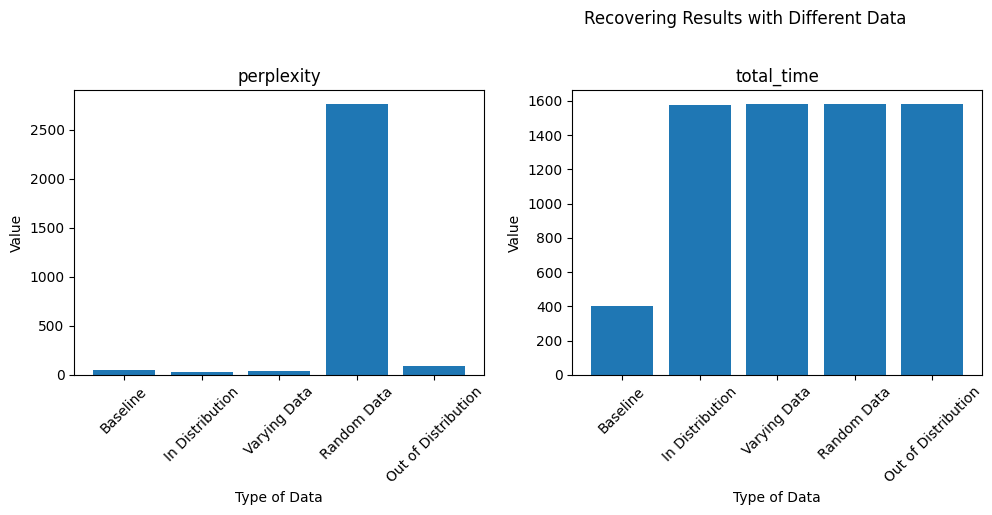

In [11]:
### To Complete ###
results = {
    "Baseline": baseline_results,
    "In Distribution": results_in_distribution,
    "Varying Data": results_varying_data,
    "Random Data": results_random_data,
    "Out of Distribution": results_out_of_distribution,
}

create_comparison_plots(
    data_dict=results,
    title="Recovering Results with Different Data",
    x_label="Type of Data",
    y_label="Value"
)
### End of To Complete ###

## Conclusion: What We've Learned About Fine-tuning LLMs

In this module, we explored how fine-tuning can help recover the quality of a quantized LLM and the data distribution influence the finetuning results. Here's a recap of the key concepts:

- **Data Quality Matters**: The quality of finetuning data is critical for post-quantization recovery.
- **Stay in-distribution**: Well-matched in-distribution data delivers the best balance of perplexity and latency.
- **Avoid mismatches**: Less aligned, out-of-distribution, or random data degradate quality, with random data being the most harmful.
- **Be careful**: Efficiency gains observed with random or out-of-distribution data reflect degraded modeling ability, not a proper optimization.


## Congratulations!

You've reached the end of the course! 🎉 

Now that you've mastered the basics of LLM efficiency, we recommend you to review the course content and try to apply the concepts you've learned to your own projects. 
We've also included some bonus sections and created several projects in the [course repository](https://github.com/PrunaAI/ai-efficiency-courses) that you can try to complete! In case you are interested in contributing to the course, please reach out to us too.

## ⭐ Bonus Exercise: Analyzing PERP Methods Across Model Architectures

As a bonus, you can try applying the same PERP method across different model architectures. It could be interesting to see how the performance of the different PERP methods varies between models and whether some methods are more robust to the model size or to variations in the recovery dataset.

**Your Tasks:**
1. For each model architecture in `MODEL_IDS`, repeat the PERP configuration and evaluation process.
2. Compare the results across different model architectures and PERP methods.

**Key questions to consider:**
- Does the performance of the different PERP methods vary between models?
- Are there any PERP methods that are more robust to the model size or recovery dataset?
- Which PERP method is the best overall?